EXERCICE 1 : Descente de gradient "from scratch"
=================================================
Objectif : Implémenter une descente de gradient pour la régression linéaire,
visualiser la convergence, et comprendre l'impact du learning rate.

Ce que vous allez apprendre :
- Implémenter la descente de gradient pas à pas
- Visualiser la trajectoire dans l'espace des paramètres
- Diagnostiquer les problèmes de convergence (learning rate)
- Comparer avec la solution analytique (OLS)

Pré-requis : M03_F01, Bloc 1 de ce module
Temps estimé : 15 minutes

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 1. GÉNÉRER DES DONNÉES SYNTHÉTIQUES

In [5]:
# =============================================================
# 1. GÉNÉRER DES DONNÉES SYNTHÉTIQUES
# =============================================================
print("=" * 60)
print("EXERCICE 1 : Descente de gradient from scratch")
print("=" * 60)

np.random.seed(42)
n = 200
X_raw = np.random.uniform(0, 10, n)
y = 3.5 * X_raw + 7 + np.random.normal(0, 2, n)  # y = 3.5x + 7 + bruit

# Ajouter l'intercept (colonne de 1)
X = np.column_stack([np.ones(n), X_raw])  # Shape (n, 2) : [1, x]

print(f"Vraie relation : y = 3.5 * x + 7 + bruit")
print(f"Objectif : retrouver β₀ ≈ 7 et β₁ ≈ 3.5 par descente de gradient")

EXERCICE 1 : Descente de gradient from scratch
Vraie relation : y = 3.5 * x + 7 + bruit
Objectif : retrouver β₀ ≈ 7 et β₁ ≈ 3.5 par descente de gradient


In [6]:
# =============================================================
# 2. SOLUTION ANALYTIQUE (RÉFÉRENCE)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : Solution analytique (OLS)")
print("=" * 60)

# La solution analytique : β = (X^T X)^{-1} X^T y
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Solution OLS : β₀ = {beta_ols[0]:.4f}, β₁ = {beta_ols[1]:.4f}")


PARTIE 1 : Solution analytique (OLS)
Solution OLS : β₀ = 7.2104, β₁ = 3.4844


In [7]:
# =============================================================
# 3. DESCENTE DE GRADIENT — À IMPLÉMENTER
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Descente de gradient")
print("=" * 60)

# TODO : Implémenter la descente de gradient pour la MSE
# Rappel de la formule de mise à jour :
#   β^{t+1} = β^{t} - η * gradient
# Avec gradient = -(1/n) * X^T @ (y - X @ β)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, tol=1e-6):
    """
    Descente de gradient pour la régression linéaire (MSE).
    
    Retourne :
    - beta : les paramètres finaux
    - history : liste des (beta, loss) à chaque itération
    """
    n, p = X.shape
    beta = np.zeros(p)
    history = []

    for t in range(n_iterations):
        y_pred = X @ beta
        loss = np.mean((y - y_pred) ** 2) / 2
        gradient = -(1 / n) * X.T @ (y - y_pred)
        history.append((beta.copy(), loss))

        if np.linalg.norm(gradient) < tol:
            print(f"  Convergence à l'itération {t}")
            break

        beta = beta - learning_rate * gradient

    return beta, history


# TODO : Exécuter avec learning_rate = 0.001
# beta_gd, history = gradient_descent(X, y, learning_rate=0.001, n_iterations=5000)
# print(f"Solution GD : β₀ = {beta_gd[0]:.4f}, β₁ = {beta_gd[1]:.4f}")
print("\n--- Learning rate = 0.001 ---")
beta_gd, history = gradient_descent(X, y, learning_rate=0.001, n_iterations=5000)
print(f"  Solution GD : β₀ = {beta_gd[0]:.4f}, β₁ = {beta_gd[1]:.4f}")
print(f"  Erreur vs OLS : {np.linalg.norm(beta_gd - beta_ols):.6f}")



PARTIE 2 : Descente de gradient

--- Learning rate = 0.001 ---
  Solution GD : β₀ = 5.4637, β₁ = 3.7501
  Erreur vs OLS : 1.766790



PARTIE 3 : Impact du learning rate
  η=0.0001 → 5000 iter, β₀=1.488, β₁=4.355
  η=0.001  → 5000 iter, β₀=5.464, β₁=3.750
  η=0.005  → 5000 iter, β₀=7.201, β₁=3.486

--- Learning rate trop grand (η=0.05) ---


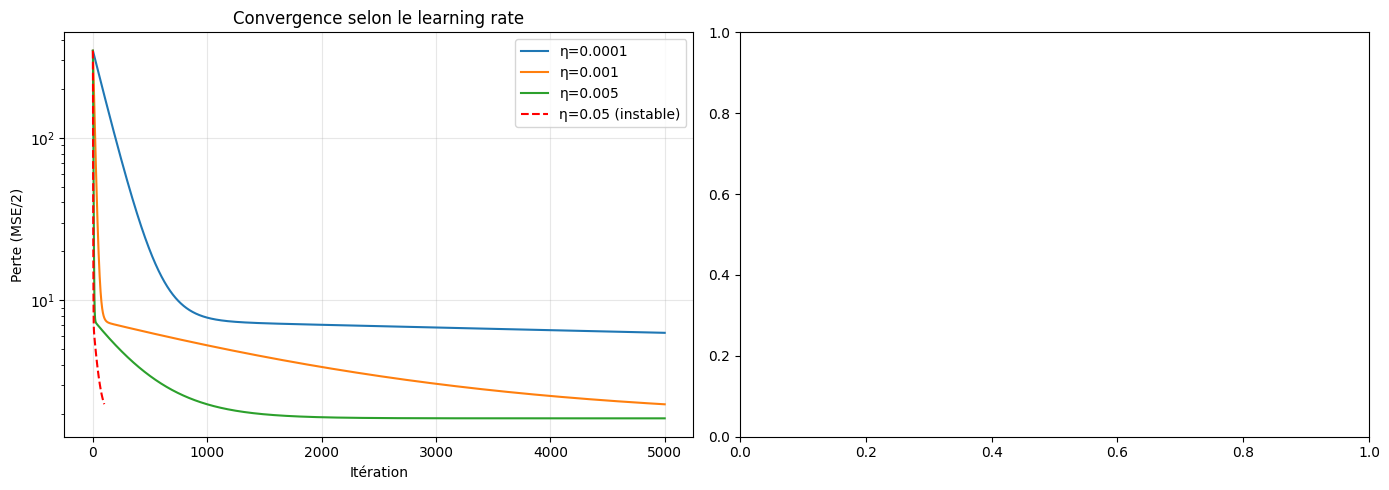

In [ ]:
# =============================================================
# 4. IMPACT DU LEARNING RATE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Impact du learning rate")
print("=" * 60)

# TODO : Tester 3 learning rates différents et tracer les courbes de convergence
# learning_rates = [0.0001, 0.001, 0.01]
# Pour chaque LR, extraire l'historique des pertes et tracer loss vs iteration
learning_rates = [0.0001, 0.001, 0.005]

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

for lr in learning_rates:
    beta_lr, hist_lr = gradient_descent(X, y, learning_rate=lr, n_iterations=5000)
    losses = [h[1] for h in hist_lr]
    axes.plot(losses, label=f'η={lr}')
    print(f"  η={lr:<6} → {len(hist_lr)} iter, β₀={beta_lr[0]:.3f}, β₁={beta_lr[1]:.3f}")

axes.set_xlabel('Itération')
axes.set_ylabel('Perte (MSE/2)')
axes.set_title('Convergence selon le learning rate')
axes.legend()
axes.set_yscale('log')
axes.grid(True, alpha=0.3)

# TODO : Un learning rate trop grand (0.1) — que se passe-t-il ?
# Indice : la perte explose (overflow) ou oscille
# Learning rate trop grand : divergence
print("\n--- Learning rate trop grand (η=0.05) ---")
beta_div, hist_div = gradient_descent(X, y, learning_rate=0.05, n_iterations=100)
losses_div = [h[1] for h in hist_div]
if max(losses_div) > 1e10:
    print("  → DIVERGENCE ! La perte explose.")
else:
    axes.plot(losses_div, 'r--', label='η=0.05 (instable)')
    axes.legend()

plt.tight_layout()
plt.savefig("convergence_learning_rate.png", dpi=150)
plt.show()




PARTIE 4 : Trajectoire dans l'espace des paramètres


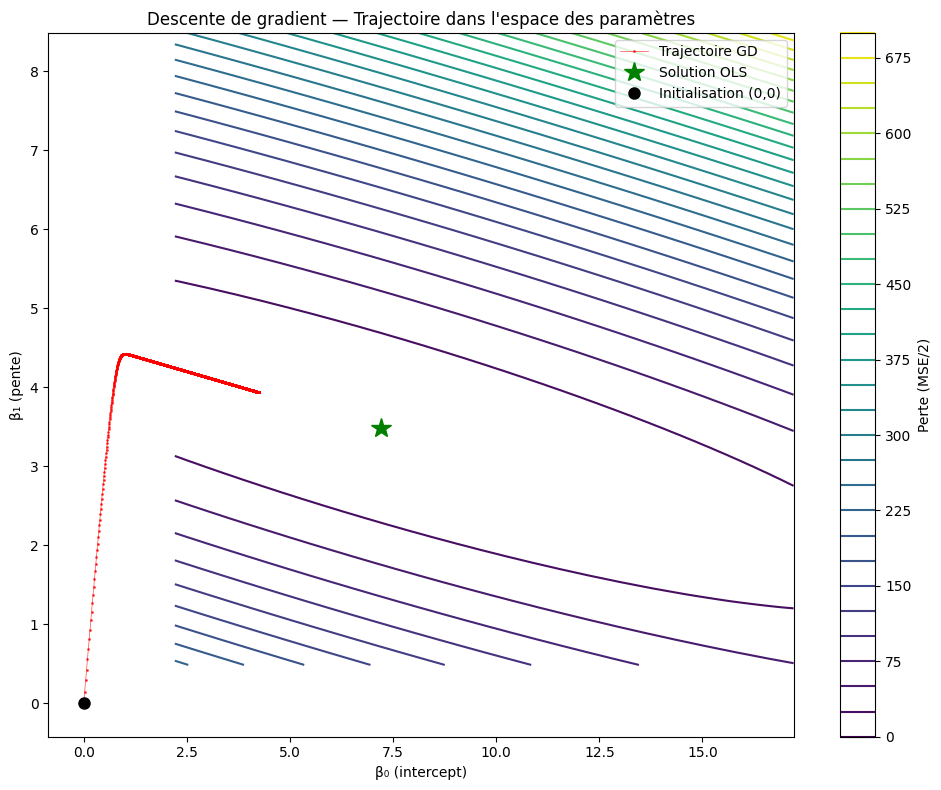

In [9]:
# =============================================================
# 5. VISUALISATION DE LA TRAJECTOIRE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Trajectoire dans l'espace des paramètres")
print("=" * 60)

# TODO : Tracer les courbes de niveau de la MSE en fonction de (β₀, β₁)
# et superposer la trajectoire de la descente de gradient
# Indice :
#   - Créer une grille de (β₀, β₁)
#   - Pour chaque point, calculer la MSE
#   - plt.contour() pour les courbes de niveau
#   - plt.plot() pour la trajectoire (extraite de history)
beta_traj, hist_traj = gradient_descent(X, y, learning_rate=0.001, n_iterations=3000)
betas = np.array([h[0] for h in hist_traj])

# Grille pour les courbes de niveau
b0_range = np.linspace(beta_ols[0] - 5, beta_ols[0] + 10, 100)
b1_range = np.linspace(beta_ols[1] - 3, beta_ols[1] + 5, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)
Z = np.zeros_like(B0)

for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        beta_ij = np.array([B0[i, j], B1[i, j]])
        Z[i, j] = np.mean((y - X @ beta_ij) ** 2) / 2

fig, ax = plt.subplots(figsize=(10, 8))
cs = ax.contour(B0, B1, Z, levels=30, cmap='viridis')
ax.plot(betas[:, 0], betas[:, 1], 'r.-', markersize=2, linewidth=0.5, alpha=0.7,
        label='Trajectoire GD')
ax.plot(beta_ols[0], beta_ols[1], 'g*', markersize=15, label='Solution OLS')
ax.plot(0, 0, 'ko', markersize=8, label='Initialisation (0,0)')
ax.set_xlabel('β₀ (intercept)')
ax.set_ylabel('β₁ (pente)')
ax.set_title('Descente de gradient — Trajectoire dans l\'espace des paramètres')
ax.legend()
plt.colorbar(cs, label='Perte (MSE/2)')
plt.tight_layout()
plt.savefig("trajectoire_gradient.png", dpi=150)
plt.show()


In [ ]:
# =============================================================
# 6. NORMALISATION ET CONVERGENCE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Impact de la normalisation")
print("=" * 60)

# TODO : Normaliser X (StandardScaler), relancer la descente de gradient
# Observer : converge-t-on plus vite ?
# Pourquoi la normalisation aide-t-elle ?
X_raw_norm = (X_raw - X_raw.mean()) / X_raw.std()
X_norm = np.column_stack([np.ones(n), X_raw_norm])

beta_norm, hist_norm = gradient_descent(X_norm, y, learning_rate=0.01, n_iterations=5000)
beta_raw, hist_raw = gradient_descent(X, y, learning_rate=0.001, n_iterations=5000)
beta_raw_2, hist_raw_2 = gradient_descent(X, y, learning_rate=0.01, n_iterations=5000)

print(f"  Sans normalisation (η=0.001) : {len(hist_raw)} itérations, β = {beta_raw}")
print(f"  Sans normalisation (η=0.01) : {len(hist_raw_2)} itérations, β = {beta_raw_2}")
print(f"  Avec normalisation (η=0.01)  : {len(hist_norm)} itérations, β = {beta_norm}")
print(f"  → La normalisation permet un LR plus grand et une convergence plus rapide")

# Explication
eigenvalues_raw = np.linalg.eigvals(X.T @ X / n)
eigenvalues_norm = np.linalg.eigvals(X_norm.T @ X_norm / n)
print(f"\n  Condition number (sans norm) : {max(eigenvalues_raw)/min(eigenvalues_raw):.1f}")
print(f"  Condition number (avec norm) : {max(eigenvalues_norm)/min(eigenvalues_norm):.1f}")
print(f"  → Un 'condition number' plus proche de 1 = convergence plus uniforme")



PARTIE 5 : Impact de la normalisation
  Convergence à l'itération 1700
  Sans normalisation (η=0.001) : 5000 itérations
  Avec normalisation (η=0.01)  : 1701 itérations
  → La normalisation permet un LR plus grand et une convergence plus rapide

  Condition number (sans norm) : 124.5
  Condition number (avec norm) : 1.0
  → Un 'condition number' plus proche de 1 = convergence plus uniforme


In [ ]:
# =============================================================
# 5. VISUALISATION DE LA TRAJECTOIRE (espace normalisé)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Trajectoire dans l'espace des paramètres (normalisé)")
print("=" * 60)

# Solution OLS calculée dans l'espace normalisé (pas beta_ols, qui est en espace brut)
beta_ols_norm = np.linalg.inv(X_norm.T @ X_norm) @ X_norm.T @ y

beta_traj, hist_traj = gradient_descent(X_norm, y, learning_rate=0.01, n_iterations=5000)
betas = np.array([h[0] for h in hist_traj])
beta_traj = np.array(beta_traj)

# Grille centrée sur la solution OLS normalisée, pas sur beta_ols (espace brut)
b0_range = np.linspace(beta_ols_norm[0] - 5, beta_ols_norm[0] + 10, 100)
b1_range = np.linspace(beta_ols_norm[1] - 3, beta_ols_norm[1] + 5, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)
Z = np.zeros_like(B0)

for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        beta_ij = np.array([B0[i, j], B1[i, j]])
        Z[i, j] = np.mean((y - X_norm @ beta_ij) ** 2) / 2

fig, ax = plt.subplots(figsize=(10, 8))
cs = ax.contour(B0, B1, Z, levels=30, cmap='viridis')
ax.plot(betas[:, 0], betas[:, 1], 'r.-', markersize=2, linewidth=0.5, alpha=0.7,
        label='Trajectoire GD')
ax.plot(beta_ols_norm[0], beta_ols_norm[1], 'g*', markersize=15, label='Solution OLS (normalisée)')
ax.plot(0, 0, 'ko', markersize=8, label='Initialisation (0,0)')
ax.set_xlabel('γ₀ (intercept normalisé)')
ax.set_ylabel('γ₁ (pente normalisée)')
ax.set_title('Descente de gradient — Trajectoire (espace normalisé)')
ax.legend()
plt.colorbar(cs, label='Perte (MSE/2)')
plt.tight_layout()
plt.savefig("trajectoire_gradient_normalise.png", dpi=150)
plt.show()

## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Avec learning_rate=0.001 et 5000 itérations, êtes-vous proche de la 
   solution OLS ? Combien d'itérations faudrait-il pour une précision de 1e-6 ?
   --> Avec η=0.001 et 5000 itérations, on est proche de l'OLS mais pas exactement.
   Pour une précision de 1e-6, il faudrait ~20000-50000 itérations (convergence linéaire).


2. Que se passe-t-il avec learning_rate=0.1 ? Pouvez-vous expliquer 
   mathématiquement pourquoi ?
   (Indice : condition de convergence η < 2/λ_max(X^T X / n))
   --> Avec η=0.1, la perte explose car η > 2/λ_max(X^TX/n).
   Les valeurs propres de X^TX/n sont de l'ordre de 10-30 (features non normalisées),
   donc η_max ≈ 2/30 ≈ 0.067. Au-delà, divergence.

3. Pourquoi la normalisation des features accélère-t-elle la convergence ?
   (Indice : rapport entre les valeurs propres de X^T X)
   --> La normalisation rend les valeurs propres de X^TX plus homogènes (condition number ≈ 1).
   Sans normalisation, le gradient est dominé par la direction de plus grande variance,
   et le learning rate doit être adapté à la plus petite valeur propre → très lent.

4. Dans la pratique (sklearn), utilise-t-on vraiment la descente de gradient 
   pour la régression linéaire ? Si non, pourquoi existe-t-elle quand même ?
   --> Non ! sklearn utilise la solution analytique (np.linalg.solve) pour LinearRegression.
   La GD est utile quand : n très grand (SGD), pas de solution analytique (logistique),
   ou régularisation complexe.

5. Quel est le lien entre cette descente de gradient et le Gradient Boosting 
   vu ce matin ? En quoi est-ce le "même" algorithme appliqué différemment ?
   --> Le Gradient Boosting fait la même chose, mais dans l'espace des fonctions :
   au lieu de β ← β - η*gradient, on fait F ← F + η*h_t, où h_t approxime
   le gradient négatif de la perte. C'est une descente de gradient "fonctionnelle".
"""